# Layout Examples

In [ ]:
from hal.hal import HardwareAwareLayout
from hal.settings import Settings

# TODO: Change this to your local path to the HAL database
PATH_TO_DATABASE = ".../hal_database/test"

## Directional code

In [18]:
from hal.codes.directional_codes import DirectionalCode

directional_code = DirectionalCode(
    v1=(18, 0), v2=(0, 4), grid_type="hex"
)

# instantiate code
hal = HardwareAwareLayout(
    name="directional_code_example_[[36,4,4]]",
    directory_path=PATH_TO_DATABASE,
    tanner_graph=directional_code.graph
)

# Place and route
hal.place(custom_pos=directional_code.positions, toric_code=True)
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
============================================== Running HAL on code: directional_code_example_[[36,4,4]] ==============================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using custom_pos layout
⏱️  'place' executed in 2.2397 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


- Route base tier edges using straightline connections: 100%|██████████| 121/121 [00:00<00:00, 2151.31it/s]
- Attempt to route higher tier edges on base tier: 100%|██████████| 22/22 [00:00<00:00, 15658.36it/s]


- Prune 0 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers: 100%|██████████| 22/22 [00:00<00:00, 176.13it/s]
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0012 seconds.
⏱️  'route' executed in 5.7441 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0009 seconds.
                                     num_tiers  avg_coupler_length  \
directional_code_example_[[36,4,4]]        2.0            3.426768   

                                     max_avg_face_switches  avg_tsvs_per_edge  \
directional_code_example_[[36,4,4]]               2.863636                2.0   

                                     num_tiers_norm  avg_coupler_length_norm  \
directional_code_example_[[36,4,4]]   

/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


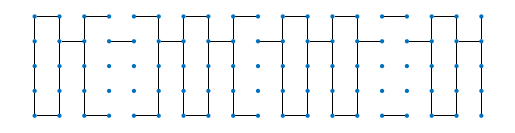

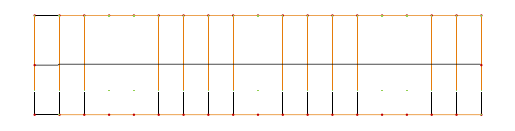

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x138f6ae90>])

In [19]:
# display the layout
hal.display()

## Bivariate bicycle code

In [ ]:
from hal.utils.disk_utils import extract_code_parameters

code_params = extract_code_parameters(r".../HAL/hal/codes/gt_params.csv")  # TODO: Change this to your local path to the gt_params.csv file

### Square layout

In [8]:
from hal.codes.generalized_toric_codes import GeneralizedToricCode

a = code_params[0]["a_coeffs"][0]
b = code_params[0]["a_coeffs"][1]
c = code_params[0]["b_coeffs"][0]
d = code_params[0]["b_coeffs"][1]
    
lattice_vectors = ((code_params[0]["a1"][0], code_params[0]["a1"][1]),
                (code_params[0]["a2"][0], code_params[0]["a2"][1]))

bb_code = GeneralizedToricCode.from_paper_parameters(
    a=a, b=b, c=c, d=d, lattice_vectors=lattice_vectors
)
node_pos = {
    node: bb_code.get_qubit_pos(node)
    for node in bb_code.graph.nodes()
}

# instantiate code
hal = HardwareAwareLayout(
    name="bb_code_square_layout_example_[[12,4,2]]",
    directory_path=PATH_TO_DATABASE,
    tanner_graph=bb_code.graph
)

# Place and route
hal.place(custom_pos=node_pos, toric_code=True)
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
=========================================== Running HAL on code: bb_code_square_layout_example_[[12,4,2]] ===========================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using custom_pos layout
⏱️  'place' executed in 2.5470 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


- Route base tier edges using straightline connections: 100%|██████████| 38/38 [00:00<00:00, 903.53it/s]
- Attempt to route higher tier edges on base tier: 100%|██████████| 34/34 [00:00<00:00, 7785.46it/s]


- Prune 0 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers: 100%|██████████| 34/34 [00:24<00:00,  1.40it/s]
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0008 seconds.
⏱️  'route' executed in 30.2846 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0005 seconds.
                                          num_tiers  avg_coupler_length  \
bb_code_square_layout_example_[[12,4,2]]        2.0            2.053438   

                                          max_avg_face_switches  \
bb_code_square_layout_example_[[12,4,2]]               3.529412   

                                          avg_tsvs_per_edge  num_tiers_norm  \
bb_code_square_layout_example_[[12,4,2]]                

/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


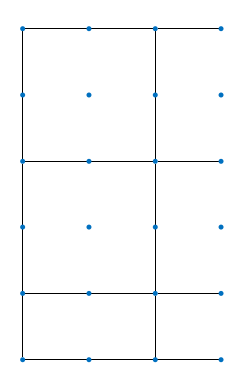

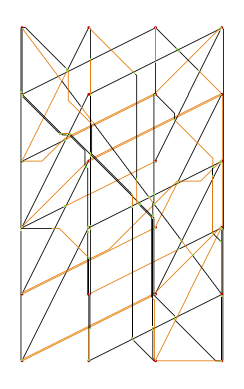

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x136c3b750>])

In [9]:
# display the layout
hal.display()

### Spring layout

In [10]:
from hal.codes.generalized_toric_codes import GeneralizedToricCode

a = code_params[0]["a_coeffs"][0]
b = code_params[0]["a_coeffs"][1]
c = code_params[0]["b_coeffs"][0]
d = code_params[0]["b_coeffs"][1]
    
lattice_vectors = ((code_params[0]["a1"][0], code_params[0]["a1"][1]),
                (code_params[0]["a2"][0], code_params[0]["a2"][1]))

bb_code = GeneralizedToricCode.from_paper_parameters(
    a=a, b=b, c=c, d=d, lattice_vectors=lattice_vectors
)

# instantiate code
hal = HardwareAwareLayout(
    name="bb_code_spring_layout_example_[[12,4,2]]",
    directory_path=PATH_TO_DATABASE,
    tanner_graph=bb_code.graph
)

# Place and route
hal.place()
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
=========================================== Running HAL on code: bb_code_spring_layout_example_[[12,4,2]] ===========================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using community layout
- Orthogonalize base tier


- Extract base layer edges: 100%|██████████| 72/72 [00:00<00:00, 234.43it/s]


- Place node positions using Kamada Kawai spring layout
- Rasterize node positions
⏱️  'place' executed in 2.9386 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


- Route base tier edges using straightline connections: 100%|██████████| 42/42 [00:00<00:00, 1712.26it/s]
- Attempt to route higher tier edges on base tier: 100%|██████████| 38/38 [00:00<00:00, 4952.57it/s]


- Prune 2 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers: 100%|██████████| 36/36 [00:15<00:00,  2.28it/s]


- Created new tier 2


/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0007 seconds.
⏱️  'route' executed in 23.9570 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0004 seconds.
                                          num_tiers  avg_coupler_length  \
bb_code_spring_layout_example_[[12,4,2]]        3.0            4.476558   

                                          max_avg_face_switches  \
bb_code_spring_layout_example_[[12,4,2]]               2.857143   

                                          avg_tsvs_per_edge  num_tiers_norm  \
bb_code_spring_layout_example_[[12,4,2]]           2.055

/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


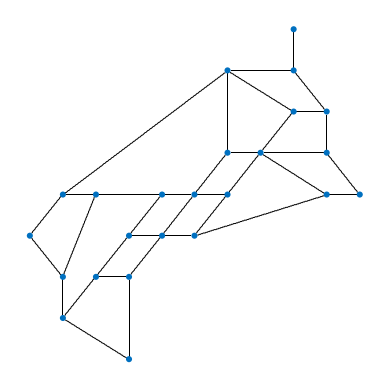

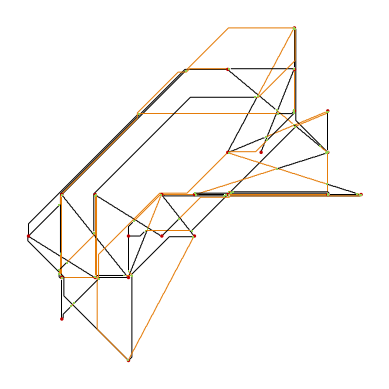

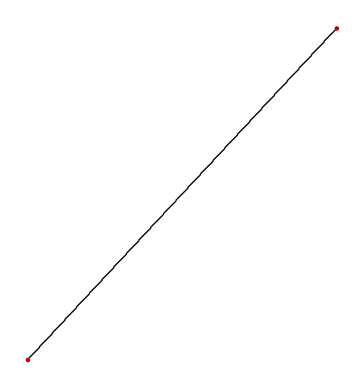

([<Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x1357a8190>])

In [11]:
# display the layout
hal.display()

## Tile code

In [36]:
from hal.codes.tile_codes import Tile, TileCode

bounding_box = (3, 4)
x_tile_edge_coords = [
    (1, 0, "h"),
    (2, 0, "h"),
    (0, 2, "h"),
    (0, 0, "v"),
    (0, 1, "v"),
    (1, 3, "v"),
]

x_tile_grid_coords = Tile.transform_edge_to_grid_coords(x_tile_edge_coords)

x_tile_params = dict(
    bounding_box=bounding_box,
    data_qubit_coords=x_tile_grid_coords,
    basis="X",
    origin=(0, 0)
)

tile_code = TileCode(
    x_tile_params=x_tile_params, 
    matrix_size=(1, 1), 
    timeout=0.1,
    x_check_qubit_coord=(0, 4),
    # enforce_max_nearest_neighbors=True
)

node_pos = tile_code.pos_dict_rich

hal = HardwareAwareLayout(
    name="tile_code_example_[[13,4,2]]",
    directory_path=PATH_TO_DATABASE,
    tanner_graph=tile_code.tanner_graph,
)

# Place and route
hal.place(custom_pos=node_pos, toric_code=True)
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

Estimating distance: dx <= 2, dz <= 2, x-weights: 2.25, z-weights: 2.00: 100%|█████████▉| 0.0996389389038086/0.1 [00:00<00:00,  1.01it/s]   
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13c280290>


🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
================================================= Running HAL on code: tile_code_example_[[13,4,2]] =================================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using custom_pos layout


DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x1388d85f0>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.


⏱️  'place' executed in 2.5103 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


- Route base tier edges using straightline connections: 100%|██████████| 10/10 [00:00<00:00, 2365.12it/s]
- Attempt to route higher tier edges on base tier: 100%|██████████| 22/22 [00:00<00:00, 1320.93it/s]


- Prune 7 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers: 100%|██████████| 15/15 [00:01<00:00,  9.94it/s]
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13c7e6810>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13c532cf0>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0005 seconds.
⏱️  'route' executed in 6.9984 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0003 seconds.
                              num_tiers  avg_coupler_length  \
tile_code_example_[[13,4,2]]        2.0            2.693011   

                              max_avg_face_switches  avg_tsvs_per_edge  \
tile_code_example_[[13,4,2]]               1.933333                2.0   

                              num_tiers_norm  avg_coupler_length_norm  \
tile_code_example_[[13,4,2]]            0.25                 0.188112   


/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


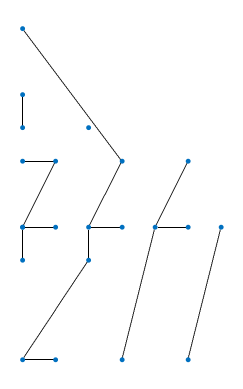

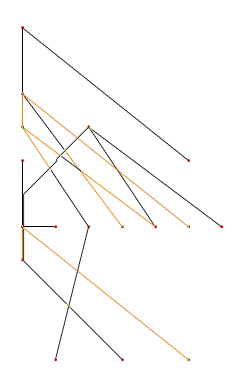

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x13a57ead0>])

In [37]:
# display the layout
hal.display()

## Radial code

In [44]:
from hal.codes.radial_codes import RadialCode

# Create a radial code
radial_code = RadialCode(r=2, s=2)

# Initialize HAL with default settings
hal = HardwareAwareLayout(
    name="radial_code_example_[[16,2,4]]",
    directory_path=PATH_TO_DATABASE,
    tanner_graph=radial_code.graph
)

# Place and route
hal.place()
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
================================================ Running HAL on code: radial_code_example_[[16,2,4]] ================================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using community layout
- Orthogonalize base tier


- Extract base layer edges: 100%|██████████| 64/64 [00:00<00:00, 434.85it/s]

- Place node positions using Kamada Kawai spring layout



DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x1408f1610>


- Rasterize node positions


...

⏱️  'place' executed in 2.7955 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


- Route base tier edges using straightline connections: 100%|██████████| 53/53 [00:00<00:00, 1788.49it/s]
- Attempt to route higher tier edges on base tier: 100%|██████████| 24/24 [00:00<00:00, 9949.92it/s]


- Prune 0 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers: 100%|██████████| 24/24 [00:05<00:00,  4.47it/s]
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x14032b650>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13e599490>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0007 seconds.
⏱️  'route' executed in 11.0286 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0004 seconds.
                                num_tiers  avg_coupler_length  \
radial_code_example_[[16,2,4]]        2.0            2.696061   

                                max_avg_face_switches  avg_tsvs_per_edge  \
radial_code_example_[[16,2,4]]               1.916667                2.0   

                                num_tiers_norm  avg_coupler_length_norm  \
radial_code_example_[[16,2,4]]            0.25                

/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


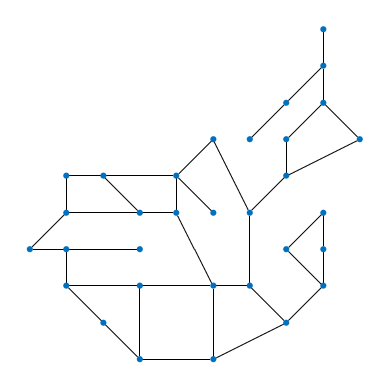

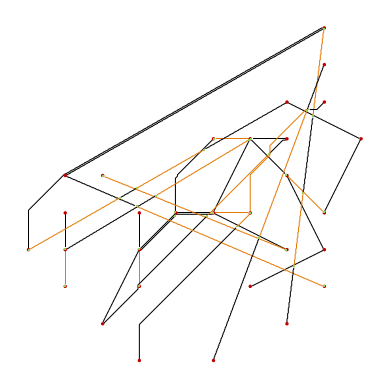

([<Figure size 640x480 with 1 Axes>, <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x140e9fd90>])

In [45]:
# display the layout
hal.display()

## Tanner code

In [ ]:
import numpy as np

# TODO: Change this to your local path to generic parity check matrix files
HX_PATH = ".../HAL/hal/codes/qTanner_pcms/D4_3_Xstabs" 
HZ_PATH = ".../HAL/hal/codes/qTanner_pcms/D4_3_Zstabs"

# load as int array
hx = np.loadtxt(HX_PATH, dtype=int)
hz = np.loadtxt(HZ_PATH, dtype=int)

pcm = np.vstack((hx, hz))

hal = HardwareAwareLayout(
    name="tanner_code_example_[[36,8,3]]",
    directory_path=PATH_TO_DATABASE,
    parity_check_matrix=pcm
)

# Place and route
hal.place()
hal.route()

# Benchmark results
results = hal.benchmark()
print(results)

🔧 HardwareAwareLayout: Using DEFAULT settings
📋 Settings(Grid: 500×500 | Layout: community | Node expansion: 1 | Edge expansion: 1 | Max bumps: 10 | Max length: 1000)
💡 Tip: Pass a Settings object to customize behavior

🔧 Placement settings: Grid: 500×500 | Layout: community | Node expansion: 1 | Place margin: 0.02
================================================ Running HAL on code: tanner_code_example_[[36,8,3]] ================================================
-------------------------------------------------------------------- Place nodes --------------------------------------------------------------------
- Order nodes using community layout
- Orthogonalize base tier


- Extract base layer edges: 100%|██████████| 192/192 [00:01<00:00, 170.34it/s]
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x1370930b0>


- Place node positions using Kamada Kawai spring layout
- Rasterize node positions


DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13a4a3950>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.


⏱️  'place' executed in 4.0704 seconds.
🔧 Routing settings: Edge expansion: 1 | Route order: length_asc | Max bumps: 10 | Max length: 1000
-------------------------------------------------------------------- Route edges --------------------------------------------------------------------


...

- Prune 3 edges that were successfully routed on base tier from higher tiers


- Route remaining edges on higher tiers:  92%|█████████▏| 100/109 [00:32<00:15,  1.67s/it]

- Created new tier 2


- Route remaining edges on higher tiers: 100%|██████████| 109/109 [00:35<00:00,  3.09it/s]
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x13c82c230>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x1388f5310>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x1383650d0>
DEBUG:matplotlib.backends.backend_pdf:Assigning font /F1 = '/opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf'
DEBUG:matplotlib.backends.backend_pdf:Embedding font /opt/anaconda3/envs/hal/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf.
DEBUG:matplotlib.backends.backend_pdf:Writing TrueType font.
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:396: R

🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0014 seconds.
⏱️  'route' executed in 45.1946 seconds.
🔧 Benchmark settings: Baseline thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge'] | Bad thresholds: ['num_tiers', 'avg_coupler_length', 'max_avg_face_switches', 'avg_tsvs_per_edge']
⏱️  'benchmark' executed in 0.0009 seconds.
                                num_tiers  avg_coupler_length  \
tanner_code_example_[[36,8,3]]        3.0            6.593514   

                                max_avg_face_switches  avg_tsvs_per_edge  \
tanner_code_example_[[36,8,3]]               3.636364           2.183486   

                                num_tiers_norm  avg_coupler_length_norm  \
tanner_code_example_[[36,8,3]]             0.5                

/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector
/opt/anaconda3/envs/hal/lib/python3.13/site-packages/netgraph/_utils.py:396: RuntimeWarning: invalid value encountered in divide
  unit_vector = vector / np.linalg.norm(vector)


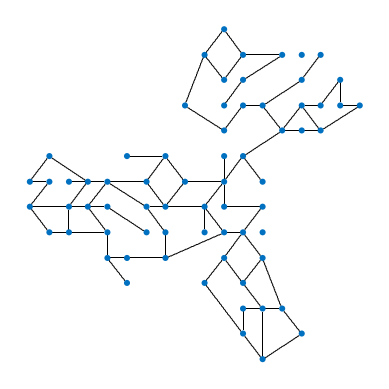

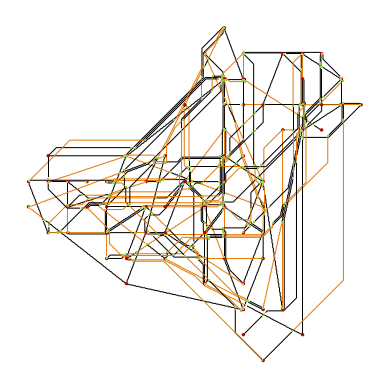

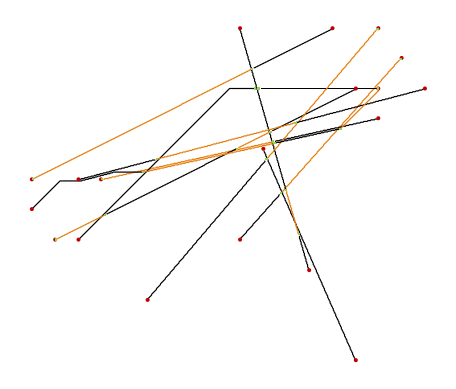

([<Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>],
  <netgraph._main.InteractiveGraph at 0x13e47e490>])

In [43]:
# display the layout
hal.display()